<a href="https://colab.research.google.com/github/FinancialWisdomAI/FinancialWisdomSimulator/blob/main/nonstationary_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

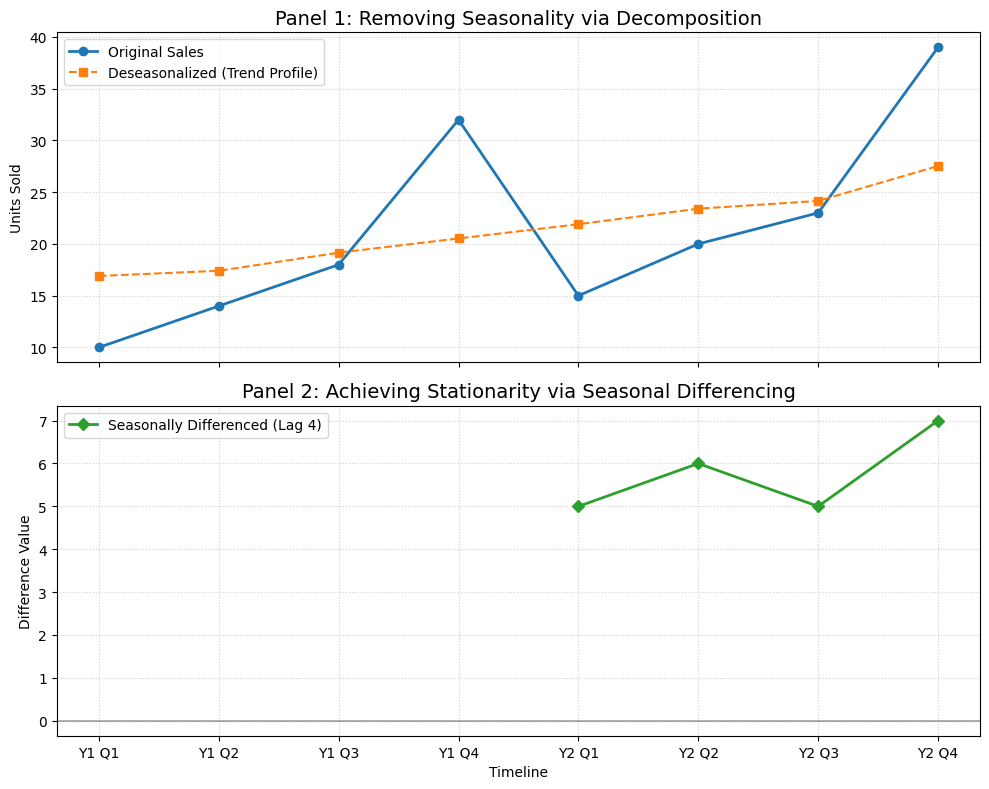

FileNotFoundError: [Errno 2] No such file or directory: '/Users/YourName/Downloads/seasonal_analysis.png'

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Create the 8-quarter sample dataset
quarters = ["Y1 Q1", "Y1 Q2", "Y1 Q3", "Y1 Q4", "Y2 Q1", "Y2 Q2", "Y2 Q3", "Y2 Q4"]
sales = [10, 14, 18, 32, 15, 20, 23, 39]

df = pd.DataFrame({"Sales": sales}, index=quarters)

# 2. Method 1: Apply Seasonal Differencing (m = 4 for quarterly data)
df["Seasonal_Diff"] = df["Sales"].diff(periods=4)

# 3. Method 2: Apply Seasonal Decomposition to isolate the trend
# We use an additive model because the seasonal spike amplitude is stable
decomposition = seasonal_decompose(df["Sales"], model="additive", period=4)
df["Deseasonalized"] = df["Sales"] - decomposition.seasonal

# 4. Plotting the results
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Panel 1: Original vs Deseasonalized (Trend)
axes[0].plot(df.index, df["Sales"], marker="o", label="Original Sales", color="tab:blue", linewidth=2)
axes[0].plot(
    df.index,
    df["Deseasonalized"],
    marker="s",
    label="Deseasonalized (Trend Profile)",
    color="tab:orange",
    linestyle="--",
)
axes[0].set_title("Panel 1: Removing Seasonality via Decomposition", fontsize=14)
axes[0].set_ylabel("Units Sold")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend()

# Panel 2: Seasonal Differencing (Stationary data)
axes[1].plot(
    df.index,
    df["Seasonal_Diff"],
    marker="D",
    label="Seasonally Differenced (Lag 4)",
    color="tab:green",
    linewidth=2,
)
axes[1].axhline(0, color="black", linestyle="-", alpha=0.3)  # Zero baseline reference
axes[1].set_title("Panel 2: Achieving Stationarity via Seasonal Differencing", fontsize=14)
axes[1].set_ylabel("Difference Value")
axes[1].set_xlabel("Timeline")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

# Save the plot as a high-quality PNG image file
plt.savefig("/Users/YourName/Downloads/seasonal_analysis.png", dpi=300, bbox_inches="tight")

# Display the underlying calculated dataframe values
print(df)

# Optional: Close the plot to free up system memory
plt.close()

